In [2]:
## load dependencies
import pandas as pd
import numpy as np
import mne
import yasa
from matplotlib import pyplot as plt
import seaborn as sns
import os

## Import EEG.edf file(s)

In [3]:
## Establish where EEG files are stored for retrieval
file_path = []

In [4]:
## import EEG.edf file and hypnogram (csv)
raw = mne.io.read_raw_edf('KellyS_Test.edf',
                          infer_types= True, ## tries to automatically understand what channel is which based on name
                           preload=True) 

## preload (default = False) preloads data into memory for faster indexing (requires large amount of memory) and may not be required but is recommended in later method below.
## mne.io.raw documentation recommends preload = True, otherwise edge artifacts appear when slices of the dignal are requested. 

Extracting EDF parameters from /Users/thomasgooding/Desktop/Git_mats/Portfolio/Data_Projects/Rutgers Research/Sleep_Profiler_SOP/KellyS_Test.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 6918399  =      0.000 ... 27024.996 secs...


In [ ]:
raw = mne.io.read_raw_edf('KellyS_Test.edf',
                          eog = ['EEG2', 'EEG3'],
                          infer_types= True, ## tries to automatically understand what channel is which based on name
                           preload=True) 

Extracting EDF parameters from /Users/thomasgooding/Desktop/Git_mats/Portfolio/Data_Projects/Rutgers Research/Sleep_Profiler_SOP/KellyS_Test.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 6918399  =      0.000 ... 27024.996 secs...


In [6]:
print(raw)

<RawEDF | KellyS_Test.edf, 26 x 6918400 (27025.0 s), ~1.34 GB, data loaded>


In [7]:
raw.info ## this is considered an attribute (vs. a method)

# attributes = static properties of Python objects- things that are pre-computed and stored as part of the object's representation in memory. Attributes are accessed with the . operator and don't require parentheses after the attribute name

Measurement date,"February 13, 2025 01:01:48 GMT"
Experimenter,Unknown
Participant,
Digitized points,Not available
Good channels,"24 EEG, 2 EOG"
Bad channels,None
EOG channels,"EEG2, EEG3"
ECG channels,Not available
Sampling frequency,256.00 Hz
Highpass,0.00 Hz
Lowpass,128.00 Hz


In [8]:
raw.info['chs'] ## a list of channel information dictionaires, one per channel. See MNE notes for more info.

## I made the channel information into a DF, for potential later use.
chs_info_df = pd.DataFrame(raw.info['chs'])

chs_info_df

,cal,logno,scanno,range,unit_mul,ch_name,unit,coord_frame,coil_type,kind,loc
0,1.0,1,1,1.0,0,EEG1,107,4,1,2,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
1,1.0,2,2,1.0,0,EEG2,107,4,0,202,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
2,1.0,3,3,1.0,0,EEG3,107,4,0,202,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
3,1.0,4,4,1.0,0,EEG4,107,4,1,2,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
4,1.0,5,5,1.0,0,Tilt1,107,4,1,2,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
5,1.0,6,6,1.0,0,Tilt2,107,4,1,2,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
6,1.0,7,7,1.0,0,Tilt3,107,4,1,2,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
7,1.0,8,8,1.0,0,IRED,107,4,1,2,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
8,1.0,9,9,1.0,0,RED,107,4,1,2,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
9,1.0,10,10,1.0,0,Snore,107,4,1,2,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."


### More Notes about raw.info
raw.info['loc'] can be used to establish channel location information. The first three elements [0:3] always store the nominal channel position. The remaining 9 elements store different information based on the channel type: 
- **EEG**: Elements [3:6] contain reference channel position
- **Eyetrack**: Element [3] contains information about which eye was tracked (-1 for left, 1 for right), and element [4] contains information about the axis of coordinate data (-1 for x-coordinate data, 1 for y-coordinate data).
- **Dipole:** Elements [3:6] contain dipole orientation information.
- **logno:** logical channel number, conventions in the usage of this number may vary.
- **range**: the hardware-oriented part of the calibraiton factor. should only be applied to continuous raw data. Used in product with [cal] to scale data read from disk.
- **events**: can include channels (list of channels) list of int.
- **hpi_meas**: things like sfreq (sample rate), nchan, first_samp, last_samp, hpi_coils (more under this last one.)
  - **Similar attributes might have relevant info I can find from Sleep Profiler's own validation studies or similar publications (e.g., operation manual).**
- **subject_info** dict. This includes first_ last_name, dob, sex, height, weight, handedness...Could potentially 'fit' our data better in future against the same dataset that YASA used...AI/ML. The Rutgers data is the testing dataset and the



**Not relevant but also included:**
- **MEG:** Remaining 9 elements [3:], contain the EX, EY, and EZ normal triplets (columns) of the coil rotation/orientation matrix.


In [9]:
## get channel names, another attribute
raw.ch_names

['EEG1',
 'EEG2',
 'EEG3',
 'EEG4',
 'Tilt1',
 'Tilt2',
 'Tilt3',
 'IRED',
 'RED',
 'Snore',
 'TC0',
 'TC1',
 'TC2',
 'TC3',
 'TC4',
 'TC5',
 'TC6',
 'TC7',
 'TC8',
 'TC9',
 'TC10',
 'TC11',
 'TC12',
 'TC13',
 'TC14',
 'TC15']

In [10]:
## drop channels TC0 to TC15. These are internal to the X8 device and not phyisological signal (may learn otherwise later)
raw.drop_channels([f'TC{i}' for i in range(16)]) # this is considered a Python method ()

## methods are specialized functions attached to an object. Usually, these require additional user input (kwargs) and/or some computation to provide a result. These always have () at the end and additional arguments go inside the ().

Measurement date,"February 13, 2025 01:01:48 GMT"
Experimenter,Unknown
Participant,
Digitized points,Not available
Good channels,"8 EEG, 2 EOG"
Bad channels,None
EOG channels,"EEG2, EEG3"
ECG channels,Not available
Sampling frequency,256.00 Hz
Highpass,0.00 Hz
Lowpass,128.00 Hz


In [ ]:
## set channel types for mapping
channel_types = {
    'EEG1':'emg', 'EEG2':'eog', 'EEG3':'eog', 'EEG4':'eeg', 'Tilt1': 'misc', 'Tilt2':'misc',
    'Tilt3':'misc', 'IRED':'bio', 'RED':'bio', 'Snore':'misc'}

raw.set_channel_types(channel_types)
## this works even though the output is a dropdown (note the Good channel types) compared to the previous windows

/var/folders/7d/370678cs0jzdr2slyl3k7m2w0000gn/T/ipykernel_49002/1898907110.py:6: RuntimeWarning: The unit for channel(s) Snore, Tilt1, Tilt2, Tilt3 has changed from V to NA.
  raw.set_channel_types(channel_types)


Measurement date,"February 13, 2025 01:01:48 GMT"
Experimenter,Unknown
Participant,
Digitized points,Not available
Good channels,"1 EMG, 2 EOG, 1 EEG, 4 misc, 2 BIO"
Bad channels,None
EOG channels,"EEG2, EEG3"
ECG channels,Not available
Sampling frequency,256.00 Hz
Highpass,0.00 Hz
Lowpass,128.00 Hz


In [12]:
print(raw.get_channel_types())

['emg', 'eog', 'eog', 'eeg', 'misc', 'misc', 'misc', 'bio', 'bio', 'misc']


## Computer Power Spectral Density

    Using multitaper spectrum estimation with 7 DPSS windows
Need more than one channel to make topography for eeg. Disabling interactivity.


/var/folders/7d/370678cs0jzdr2slyl3k7m2w0000gn/T/ipykernel_49002/1489823105.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.compute_psd(method='multitaper', fmax=50).plot(picks='data', exclude='bads', amplitude=False)
/opt/anaconda3/envs/SleepEEgPy/lib/python3.11/site-packages/mne/viz/utils.py:165: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


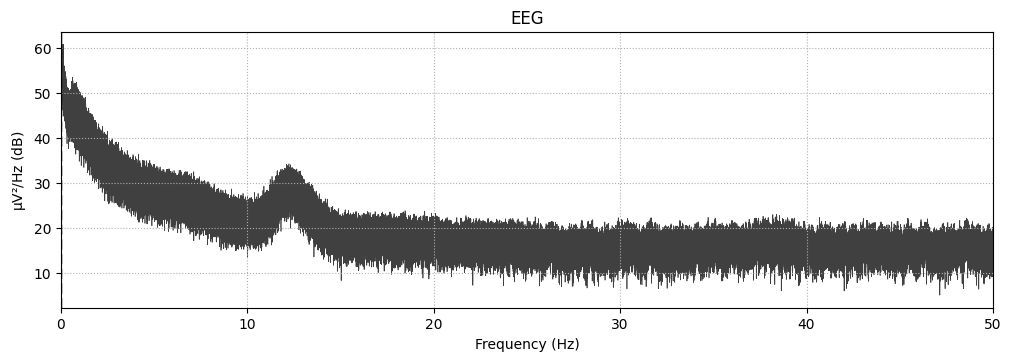

In [ ]:
raw.compute_psd(method='multitaper', fmax=50).plot(picks='data', exclude='bads', amplitude=False)
## Unsure why it shows two plots instead of expected 1

In [25]:
## set channel types for mapping
channel_types = {
    'EEG1':'emg', 'EEG2':'eog', 'EEG3':'eog', 'EEG4':'eeg', 'Tilt1': 'misc', 'Tilt2':'misc',
    'Tilt3':'misc', 'IRED':'bio', 'RED':'bio', 'Snore':'misc'}

raw.set_channel_types(channel_types)
## this works even though the output is a dropdown (note the Good channel types) compared to the previous windows

Measurement date,"February 13, 2025 01:01:48 GMT"
Experimenter,Unknown
Participant,
Digitized points,Not available
Good channels,"1 EMG, 2 EOG, 1 EEG, 4 misc, 2 BIO"
Bad channels,None
EOG channels,"EEG2, EEG3"
ECG channels,Not available
Sampling frequency,256.00 Hz
Highpass,0.00 Hz
Lowpass,128.00 Hz


Effective window size : 8.000 (s)
Need more than one channel to make topography for eeg. Disabling interactivity.


/var/folders/7d/370678cs0jzdr2slyl3k7m2w0000gn/T/ipykernel_49002/2195506732.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.compute_psd(method='welch', fmax=50).plot(picks='data', exclude='bads', amplitude=False)
/opt/anaconda3/envs/SleepEEgPy/lib/python3.11/site-packages/mne/viz/utils.py:165: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


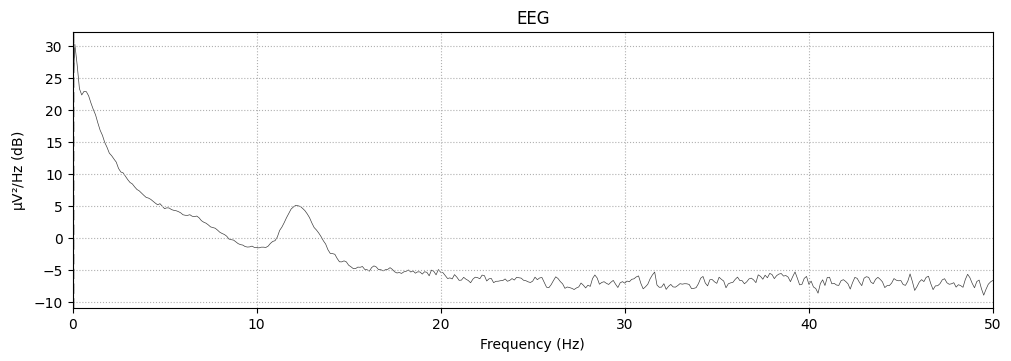

In [ ]:


raw.compute_psd(method='welch', fmax=50).plot(picks='data', exclude='bads', amplitude=False)

# Import Hypnogram data


Look at columns below:
- Primary autostage is SleepProfiler's initial scoring of each 30s epoch, 
- Secondary autostage would be the classification if a stage was "light N2" or had partial scoring between two stages, 
- TechEditStage would be the epoch's score if a researcher manually changed that epoch's stage from Sleep Profiler's algorithm. 


  
- Stagefinal is the final score for each 30-s epoch (each row = 30s epoch). **Use this one.**

In [126]:
## import hypnogram
hypno_df = pd.read_csv('KellyS_epoch_data.csv')

hypno_df.head()

,Subject #,Epoch #,Night,StudyDate,ElapsedTime,ElapsedTime(sec),ClockTime,PrimaryAutoStage,SecondaryAutoStage,TechEditStage,Stage final,ChannelStaged,ImpLEOG,ImpREOG,ImpEEG
0,421000303,1,1,13-Feb-25,0:00:31,31,1:02:22,0,0,NaN,0,EEG,4,2,6
1,421000303,2,1,13-Feb-25,0:01:01,61,1:02:52,0,0,NaN,0,EEG,4,2,6
2,421000303,3,1,13-Feb-25,0:01:31,91,1:03:22,0,0,NaN,0,EEG,4,2,6
3,421000303,4,1,13-Feb-25,0:02:01,121,1:03:52,0,0,NaN,0,EEG,4,2,6
4,421000303,5,1,13-Feb-25,0:02:31,151,1:04:22,0,0,NaN,0,EEG,4,2,6


In [127]:
hypno_df.describe()
## count = 899 of 30 second epochs = 449.5 minutes

,Subject #,Epoch #,Night,ElapsedTime(sec),PrimaryAutoStage,SecondaryAutoStage,TechEditStage,Stage final,ImpLEOG,ImpREOG,ImpEEG
count,899.0,899.000000,899.0,899.000000,899.000000,899.000000,0.0,899.000000,899.000000,899.000000,899.000000
mean,421000303.0,450.000000,1.0,13501.000000,2.652948,2.598443,NaN,2.652948,1.529477,26.291435,35.028921
std,0.0,259.663243,0.0,7789.897304,1.344675,1.372672,NaN,1.344675,0.760940,75.325483,85.211653
min,421000303.0,1.000000,1.0,31.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000
25%,421000303.0,225.500000,1.0,6766.000000,2.000000,2.000000,NaN,2.000000,1.000000,1.000000,1.000000
50%,421000303.0,450.000000,1.0,13501.000000,2.000000,2.000000,NaN,2.000000,1.000000,1.000000,1.000000
75%,421000303.0,674.500000,1.0,20236.000000,3.000000,3.000000,NaN,3.000000,2.000000,2.000000,2.000000
max,421000303.0,899.000000,1.0,26971.000000,5.000000,5.000000,NaN,5.000000,4.000000,252.000000,252.000000


In [128]:
hypno_df.columns = hypno_df.columns.str.lower().str.replace(' ', '_')

hypno_df.columns

Index(['subject_#', 'epoch_#', 'night', 'studydate', 'elapsedtime',
       'elapsedtime(sec)', 'clocktime', 'primaryautostage',
       'secondaryautostage', 'techeditstage', 'stage_final', 'channelstaged',
       'impleog', 'impreog', 'impeeg'],
      dtype='object')

In [129]:
## map hypnogram stages based on SleepProfiler stage scoring documentation
stage_map = {
    0 : 'WAKE',
    1: 'N1',
    2: 'N2',
    3: 'N3',
    4: 'N2', ## Light N2 (Still N2)
    5: 'REM', 
    6: 'UNS', ## sleep not otherwise specified
    9: 'UNS', ## artifact/ INVALID
    14: 'N2',
    33: 'N3', ## atypical N3, mapped to N3
    55: 'REM' ## REM without atonia, mapped to REM
}

hypno_df_sorted = hypno_df.sort_values('epoch_#').copy()
hypno_df_sorted['yasa_stage'] = hypno_sorted['stage_final'].map(stage_map)

# Check nothing fell through unmapped
print(hypno_df_sorted["yasa_stage"].isna().sum(), "unmapped epochs")

stage_sequence = hypno_df_sorted["yasa_stage"].values
hyp = yasa.Hypnogram(stage_sequence, freq="30s")

0 unmapped epochs


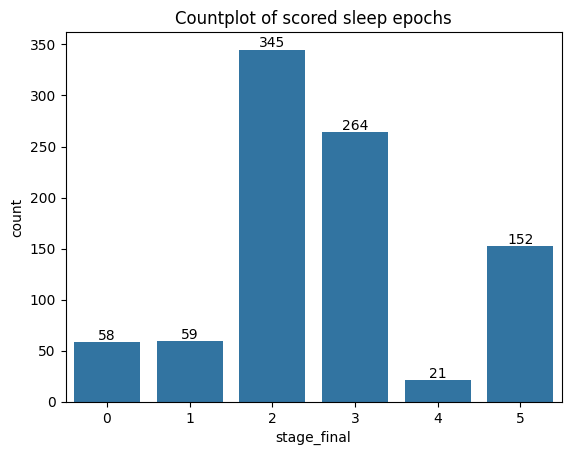

In [131]:
ax = sns.countplot(data= hypno_df, x='stage_final')
ax.bar_label(ax.containers[0], label_type = 'edge')

ax.set_title('Countplot of scored sleep epochs')
plt.show()

## 899 total count (30s) = 449.5 min, the TIB values from hypnogram.sleep_statistics() below

/var/folders/7d/370678cs0jzdr2slyl3k7m2w0000gn/T/ipykernel_49002/495390205.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(stage_labels.values())


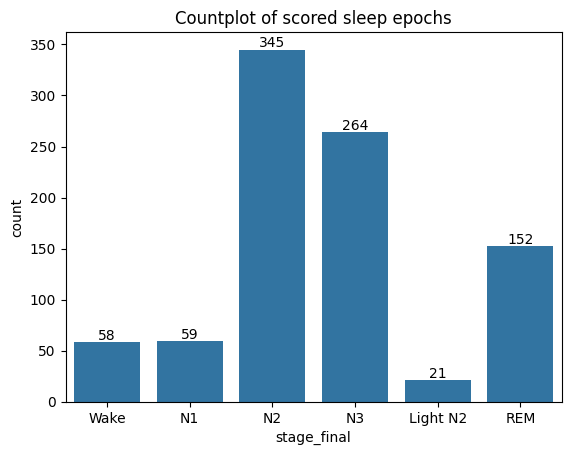

In [130]:
ax = sns.countplot(data= hypno_df, x='stage_final')
ax.bar_label(ax.containers[0], label_type = 'edge')

## labels based on SleepProfiler documentation
stage_labels = {
    0 : 'Wake',
    1 : 'N1',
    2 : 'N2',
    3 : 'N3', 
    4 : 'Light N2',
    5 : 'REM'
}

ax.set_xticklabels(stage_labels.values())
ax.set_title('Countplot of scored sleep epochs')
plt.show()

## 899 total count (30s) = 449.5 min, the TIB values from hypnogram.sleep_statistics() below

/var/folders/7d/370678cs0jzdr2slyl3k7m2w0000gn/T/ipykernel_49002/1964525906.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(stage_labels.values())


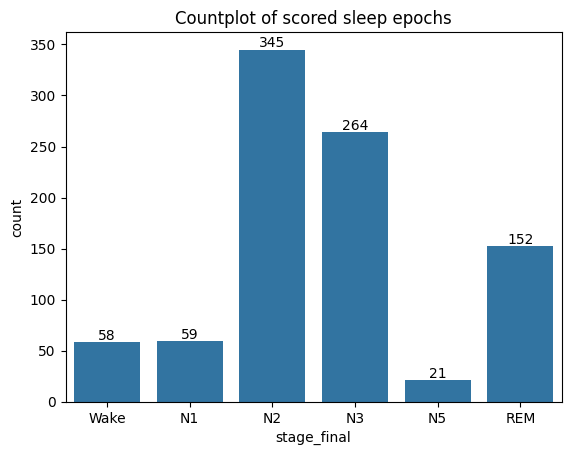

In [32]:
ax = sns.countplot(data= hypno, x='stage_final')
ax.bar_label(ax.containers[0], label_type = 'edge')

## labels based on SleepProfiler documentation
stage_labels = {
    0 : 'Wake',
    1 : 'N1',
    2 : 'N2',
    3 : 'N3', 
    4 : 'N5',
    5 : 'REM'
}

ax.set_xticklabels(stage_labels.values())
ax.set_title('Countplot of scored sleep epochs')
plt.show()

## 899 total count (30s) = 449.5 min, the TIB values from hypnogram.sleep_statistics() below

# Sleep Staging

In [33]:
## map hypnogram stages based on SleepProfiler stage scoring documentation
stage_map = {
    0 : 'WAKE',
    1: 'N1',
    2: 'N2',
    3: 'N3',
    4: 'N2', ## Light N2 (Still N2)
    5: 'REM', 
    6: 'UNS', ## sleep not otherwise specified
    9: 'UNS', ## artifact/ INVALID
    14: 'N2',
    33: 'N3', ## atypical N3, mapped to N3
    55: 'REM' ## REM without atonia, mapped to REM
}

hypno_sorted = hypno.sort_values('epoch_#').copy()
hypno_sorted['yasa_stage'] = hypno_sorted['stage_final'].map(stage_map)

# Check nothing fell through unmapped
print(hypno_sorted["yasa_stage"].isna().sum(), "unmapped epochs")

stage_sequence = hypno_sorted["yasa_stage"].values
hyp = yasa.Hypnogram(stage_sequence, freq="30s")

0 unmapped epochs


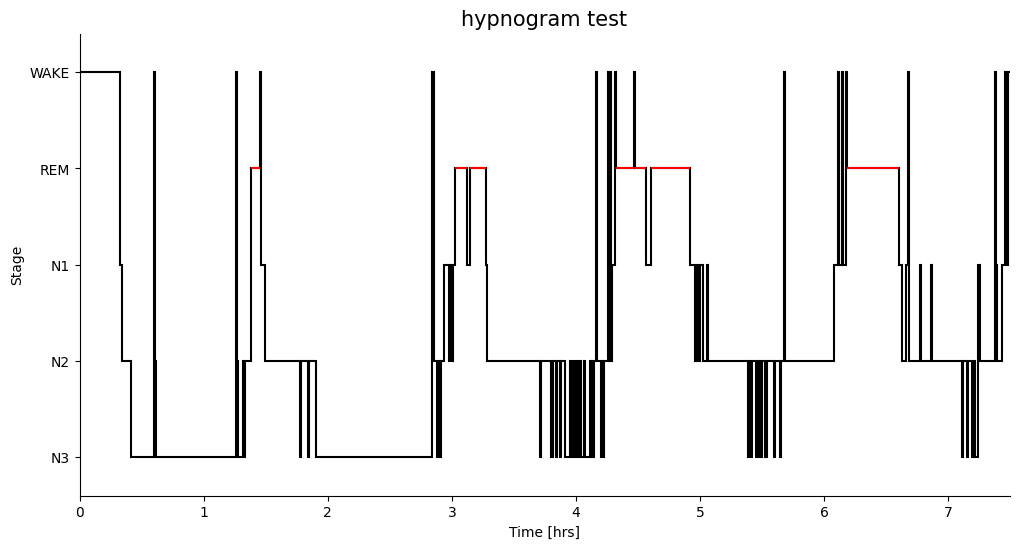

In [34]:
fig, ax = plt.subplots(figsize=(12,6))

ax = hyp.plot_hypnogram()

plt.title('hypnogram test', fontsize=15)
plt.show()

# Sleep Statistics

In [35]:
hyp.sleep_statistics()


{'TIB': 449.5,
 'SPT': 429.5,
 'WASO': 9.0,
 'TST': 420.5,
 'SE': 93.5484,
 'SME': 97.9045,
 'SFI': 1.2128,
 'SOL': 19.5,
 'SOL_5min': 19.5,
 'Lat_REM': 83.0,
 'WAKE': 29.0,
 'N1': 29.5,
 'N2': 183.0,
 'N3': 132.0,
 'REM': 76.0,
 '%N1': 7.0155,
 '%N2': 43.5196,
 '%N3': 31.3912,
 '%REM': 18.0737}

In [36]:
counts, probs = hyp.transition_matrix()

## counts = number of transitions from stage A to B. pre-transition states are the rows and the post-transition states are the columns
display(counts)

## conditional probability transition matrix, i.e., given that current state is A, what is the probability that the next state is B. Stochastic matrix
display(probs.round(3))

To Stage,WAKE,N1,N2,N3,REM
From Stage,,,,,
WAKE,40,6,8,0,3
N1,7,35,14,0,3
N2,5,12,313,35,1
N3,3,1,31,229,0
REM,2,5,0,0,145


To Stage,WAKE,N1,N2,N3,REM
From Stage,,,,,
WAKE,0.702,0.105,0.140,0.000,0.053
N1,0.119,0.593,0.237,0.000,0.051
N2,0.014,0.033,0.855,0.096,0.003
N3,0.011,0.004,0.117,0.867,0.000
REM,0.013,0.033,0.000,0.000,0.954


In [37]:
## the stability of sleep can be calculated by taking the average of the diagonal values of N2, N3, and REM sleep
np.diag(probs.loc['N2':, "N2":]).mean().round(3)

0.892

In [38]:
rem = yasa.rem_detect(
    loc=raw.get_data(picks='EEG3')[0] * 1e6,  # LEOG confirmed
    roc=raw.get_data(picks='EEG2')[0] * 1e6,  # REOG confirmed
    sf=raw.info['sfreq'],
    hypno=hyp,
    include=4,  # REM stage
)

31-Aug-26 12:34:41 | WARNING | Hypnogram is SHORTER than data by 55.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.1s finished


## Spectrogram

31-Aug-26 13:08:04 | WARNING | Hypnogram is SHORTER than data by 55.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.


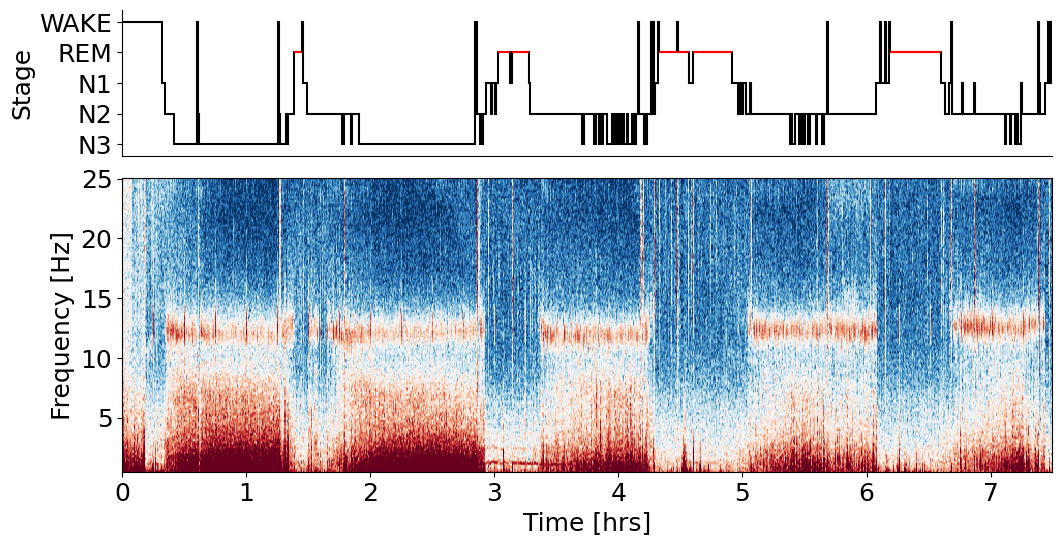

In [83]:
## Specify channel for spectral estimation analysis
data_chan = raw.get_data(picks='EEG4')[0]
## Specify sampling frequency (256 Hz)
sf = raw.info['sfreq']

## Plot spectrogram
yasa.plot_spectrogram(data_chan, sf, hyp)

## Bandpower

In [84]:
## EEG power in specific frequency bands
## default is that this is in relative power across all channels
eeg_channels = ['EEG4']
raw_eeg = raw.copy().pick(eeg_channels)

yasa.bandpower(raw_eeg, ch_names=['EEG4'], relative=False)

,Delta,Theta,Alpha,Sigma,Beta,Gamma,TotalAbsPow,FreqRes,Relative
Chan,,,,,,,,,
EEG4,33.56237,5.069504,2.038243,1.433623,1.089211,0.213108,43.406059,0.25,False


In [85]:
## EEG power in specific frequency bands
## here is the absolute power across all channels
## yuck to look at
yasa.bandpower(raw_eeg, relative=False)

,Delta,Theta,Alpha,Sigma,Beta,Gamma,TotalAbsPow,FreqRes,Relative
Chan,,,,,,,,,
EEG4,33.56237,5.069504,2.038243,1.433623,1.089211,0.213108,43.406059,0.25,False


In [86]:
## can also pass a hypnogram to calculate the spectral powers separately for each sleep stage. In the example belo, we pass hypnogram object directly and use string stage labels for include. then, save the results in a new variable named 'bandpower'
bandpower = yasa.bandpower(raw_eeg, hypno = hyp, include=['N2', 'N3', 'REM'])

bandpower

31-Aug-26 13:09:00 | WARNING | Hypnogram is SHORTER than data by 55.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.


,,Delta,Theta,Alpha,Sigma,Beta,Gamma,TotalAbsPow,FreqRes,Relative
Stage,Chan,,,,,,,,,
2,EEG4,0.710564,0.121066,0.068695,0.063850,0.030283,0.005542,38.376501,0.25,True
3,EEG4,0.923541,0.049839,0.014855,0.008527,0.002712,0.000527,303.299516,0.25,True
4,EEG4,0.673135,0.150911,0.046396,0.031476,0.080664,0.017417,14.019210,0.25,True


## Sleep Spindle Analysis

In [75]:
## isolate EEG channel(s) or spindle_detect will occur on all possible channels
eeg_channels = ['EEG4']
raw_eeg = raw.copy().pick(eeg_channels)

sp = yasa.spindles_detect(raw_eeg, hypno= hyp, include=['N2', 'N3'])

sp.summary()

## sp variable is a SpindlesResults (bundle of functions called methods) and data (attributes). 

31-Aug-26 12:56:28 | WARNING | Hypnogram is SHORTER than data by 55.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.1s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.1s finished


,Start,Peak,End,Duration,Amplitude,AmpFiltered,RMS,AbsPower,RelPower,Frequency,Oscillations,Symmetry,Stage,Channel,IdxChannel
0,1252.199219,1252.402344,1252.812500,0.613281,31.463677,14.734405,6.713212,1.477557,0.261957,12.606399,8.0,0.329114,2,EEG4,0
1,1259.839844,1260.136719,1260.492188,0.652344,43.039372,25.444722,9.246004,1.818899,0.364423,12.469450,8.0,0.452381,2,EEG4,0
2,1268.132812,1268.382812,1269.207031,1.074219,31.219279,23.042778,6.887620,1.562799,0.449959,12.472698,13.0,0.231884,2,EEG4,0
3,1274.785156,1274.996094,1275.597656,0.812500,24.469550,16.380466,5.668907,1.648784,0.525266,12.504452,10.0,0.258373,2,EEG4,0
4,1277.519531,1278.160156,1278.429688,0.910156,40.158593,23.218884,7.907250,1.752384,0.446534,12.688810,10.0,0.700855,2,EEG4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1265,26726.738281,26727.050781,26727.425781,0.687500,27.124713,18.829397,5.952717,1.668712,0.547866,13.218066,9.0,0.451977,2,EEG4,0
1266,26738.371094,26738.847656,26739.406250,1.035156,45.976382,28.786705,9.626578,2.175429,0.671251,13.050696,14.0,0.458647,2,EEG4,0
1267,26741.902344,26742.300781,26742.796875,0.894531,52.454372,43.522232,11.304587,2.210276,0.646790,12.942289,12.0,0.443478,2,EEG4,0
1268,26748.722656,26749.187500,26749.683594,0.960938,33.468267,17.886285,7.587170,1.785331,0.517889,12.753991,12.0,0.481781,2,EEG4,0


In [87]:
sp.summary(grp_chan=True, grp_stage=True)

## specifying grp_chan and grp_stage parameters tells YASA to first average across channels and sleep stages

,,Count,Density,Duration,Amplitude,AmpFiltered,RMS,AbsPower,RelPower,Frequency,Oscillations,Symmetry
Stage,Channel,,,,,,,,,,,
2,EEG4,1105,6.038251,0.935276,38.269948,24.256031,8.326675,1.830783,0.459964,12.471021,11.415385,0.502539
3,EEG4,165,1.250000,0.830658,46.292419,28.684517,10.417635,1.964526,0.378663,12.383619,10.006061,0.485398


In [72]:
# ## another way to do this without changing raw at all

# sp = yasa.spindles_detect(
#     raw.get_data(picks='EEG4')[0] * 1e6,  # µV, single channel
#     raw.info['sfreq'],
#     hypno=hyp,
#     include=("N2", "N3"),   ## N2 and N3 only
#     freq_sp=(12, 15), ## spindle frequency band. Can adjust for slow (11-13Hz) vs fast (13-15Hz)
#     freq_broad=(1, 30),
#     min_distance=500, ## ms between spindles
#     # coupling=True,    ## spindle-SO coupling
# )
# sp_summary = sp.summary(grp_stage=True)  ## aggregate by sleep stage

# sp.summary()

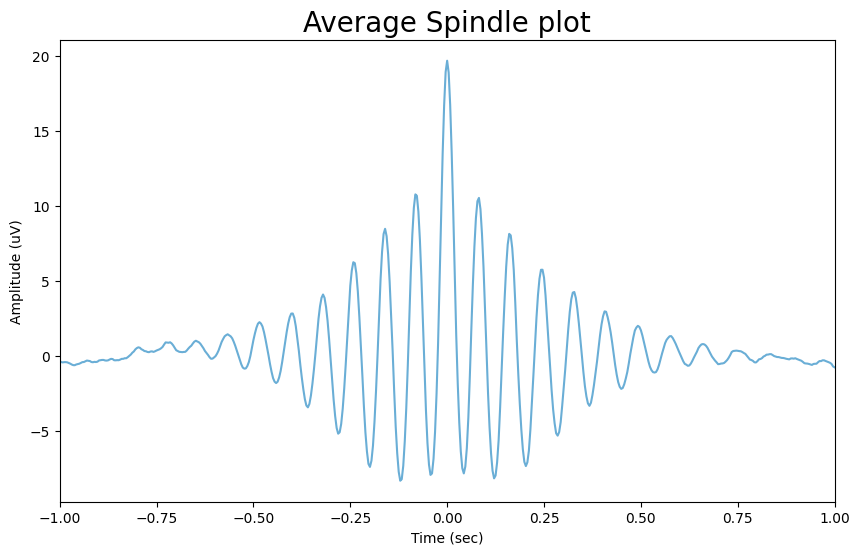

In [66]:
sp.plot_average(ci=None, legend=False, palette='Blues', figsize=(10,6))

plt.title('Average Spindle plot', fontsize=20)
plt.show()

In [77]:
sp_summary

,Count,Density,Duration,Amplitude,AmpFiltered,RMS,AbsPower,RelPower,Frequency,Oscillations,Symmetry
Stage,,,,,,,,,,,
2,1105,6.038251,0.935276,38.269948,24.256031,8.326675,1.830783,0.459964,12.471021,11.415385,0.502539
3,165,1.250000,0.830658,46.292419,28.684517,10.417635,1.964526,0.378663,12.383619,10.006061,0.485398


In [78]:
sp.summary()

,Start,Peak,End,Duration,Amplitude,AmpFiltered,RMS,AbsPower,RelPower,Frequency,Oscillations,Symmetry,Stage,Channel,IdxChannel
0,1252.199219,1252.402344,1252.812500,0.613281,31.463677,14.734405,6.713212,1.477557,0.261957,12.606399,8.0,0.329114,2,EEG4,0
1,1259.839844,1260.136719,1260.492188,0.652344,43.039372,25.444722,9.246004,1.818899,0.364423,12.469450,8.0,0.452381,2,EEG4,0
2,1268.132812,1268.382812,1269.207031,1.074219,31.219279,23.042778,6.887620,1.562799,0.449959,12.472698,13.0,0.231884,2,EEG4,0
3,1274.785156,1274.996094,1275.597656,0.812500,24.469550,16.380466,5.668907,1.648784,0.525266,12.504452,10.0,0.258373,2,EEG4,0
4,1277.519531,1278.160156,1278.429688,0.910156,40.158593,23.218884,7.907250,1.752384,0.446534,12.688810,10.0,0.700855,2,EEG4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1265,26726.738281,26727.050781,26727.425781,0.687500,27.124713,18.829397,5.952717,1.668712,0.547866,13.218066,9.0,0.451977,2,EEG4,0
1266,26738.371094,26738.847656,26739.406250,1.035156,45.976382,28.786705,9.626578,2.175429,0.671251,13.050696,14.0,0.458647,2,EEG4,0
1267,26741.902344,26742.300781,26742.796875,0.894531,52.454372,43.522232,11.304587,2.210276,0.646790,12.942289,12.0,0.443478,2,EEG4,0
1268,26748.722656,26749.187500,26749.683594,0.960938,33.468267,17.886285,7.587170,1.785331,0.517889,12.753991,12.0,0.481781,2,EEG4,0


## Slow Wave Statistics

In [104]:
## isolating EEG channel(s)
eeg_channels = ['EEG4']
raw_eeg = raw.copy().pick(eeg_channels)

sw = yasa.sw_detect(raw_eeg, 
                    hypno= hyp, 
                    include=['N2', 'N3'], ## stages 2,3 are default
                    freq_sw = (0.3,1.5), ## default (0.3 to 1.5 Hz)
                    # dur_neg,
                    # dur_pos,
                    coupling=True
                    )

sw.summary()

## AASM slow wave defined as 0.5–2.0 Hz, p2p amplitude of >75μV, measured over the frontal region

31-Aug-26 14:07:02 | WARNING | Hypnogram is SHORTER than data by 55.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.1s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.1s finished


,Start,NegPeak,MidCrossing,PosPeak,End,Duration,ValNegPeak,ValPosPeak,PTP,Slope,Frequency,SigmaPeak,PhaseAtSigmaPeak,ndPAC,Stage,Channel,IdxChannel
0,1719.386719,1719.691406,1719.953125,1720.167969,1720.421875,1.0352,-57.968922,39.683884,97.652806,221.493194,0.965997,1718.839844,2.247498,0.300780,3,EEG4,0
1,1871.105469,1871.390625,1871.707031,1872.003906,1872.359375,1.2539,-50.867305,41.846577,92.713882,160.765803,0.797512,1870.496094,-1.531112,0.258033,3,EEG4,0
2,1927.859375,1928.078125,1928.292969,1928.546875,1929.238281,1.3789,-52.036277,57.114201,109.150478,242.205218,0.725216,1927.394531,-2.078998,0.271956,3,EEG4,0
3,1947.660156,1947.953125,1948.281250,1948.953125,1949.222656,1.5625,-71.996406,75.190161,147.186567,219.417620,0.640000,1948.371094,-1.300246,0.422977,3,EEG4,0
4,1949.222656,1949.500000,1949.843750,1950.136719,1950.421875,1.1992,-68.926498,49.200598,118.127095,200.513448,0.833889,1948.500000,-1.127061,0.349446,3,EEG4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
651,25653.121094,25653.402344,25653.636719,25653.835938,25654.070312,0.9492,-86.580396,65.346880,151.927275,369.409688,1.053519,25652.738281,-2.804493,0.000000,2,EEG4,0
652,25981.136719,25981.402344,25981.734375,25981.921875,25982.496094,1.3594,-64.283615,14.698960,78.982575,193.607121,0.735619,25981.953125,-0.736251,0.381566,3,EEG4,0
653,26117.996094,26118.277344,26118.511719,26118.750000,26119.437500,1.4414,-79.066852,70.794921,149.861773,337.351902,0.693770,26117.773438,-0.054329,0.129387,2,EEG4,0
654,26119.437500,26119.718750,26119.988281,26120.148438,26120.332031,0.8945,-86.677698,34.679142,121.356840,321.586820,1.117943,26120.187500,-0.138124,0.264104,2,EEG4,0


In [97]:
sw.summary()

,Start,NegPeak,MidCrossing,PosPeak,End,Duration,ValNegPeak,ValPosPeak,PTP,Slope,Frequency,SigmaPeak,PhaseAtSigmaPeak,ndPAC,Stage,Channel,IdxChannel
0,1719.386719,1719.691406,1719.953125,1720.167969,1720.421875,1.0352,-57.968922,39.683884,97.652806,221.493194,0.965997,1718.839844,2.247498,0.300780,3,EEG4,0
1,1871.105469,1871.390625,1871.707031,1872.003906,1872.359375,1.2539,-50.867305,41.846577,92.713882,160.765803,0.797512,1870.496094,-1.531112,0.258033,3,EEG4,0
2,1927.859375,1928.078125,1928.292969,1928.546875,1929.238281,1.3789,-52.036277,57.114201,109.150478,242.205218,0.725216,1927.394531,-2.078998,0.271956,3,EEG4,0
3,1947.660156,1947.953125,1948.281250,1948.953125,1949.222656,1.5625,-71.996406,75.190161,147.186567,219.417620,0.640000,1948.371094,-1.300246,0.422977,3,EEG4,0
4,1949.222656,1949.500000,1949.843750,1950.136719,1950.421875,1.1992,-68.926498,49.200598,118.127095,200.513448,0.833889,1948.500000,-1.127061,0.349446,3,EEG4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
651,25653.121094,25653.402344,25653.636719,25653.835938,25654.070312,0.9492,-86.580396,65.346880,151.927275,369.409688,1.053519,25652.738281,-2.804493,0.000000,2,EEG4,0
652,25981.136719,25981.402344,25981.734375,25981.921875,25982.496094,1.3594,-64.283615,14.698960,78.982575,193.607121,0.735619,25981.953125,-0.736251,0.381566,3,EEG4,0
653,26117.996094,26118.277344,26118.511719,26118.750000,26119.437500,1.4414,-79.066852,70.794921,149.861773,337.351902,0.693770,26117.773438,-0.054329,0.129387,2,EEG4,0
654,26119.437500,26119.718750,26119.988281,26120.148438,26120.332031,0.8945,-86.677698,34.679142,121.356840,321.586820,1.117943,26120.187500,-0.138124,0.264104,2,EEG4,0


In [ ]:
sw.summary(grp_chan=True, grp_stage=True)

## Per documentation, (https://yasa-sleep.org/generated/yasa.sw_detect.html)

,,Count,Density,Duration,ValNegPeak,ValPosPeak,PTP,Slope,Frequency,PhaseAtSigmaPeak,ndPAC
Stage,Channel,,,,,,,,,,
2,EEG4,41,0.224044,1.353571,-57.943320,48.456348,106.399668,199.826249,0.783758,1.446359,0.315707
3,EEG4,615,4.659091,1.259235,-57.600021,48.814052,106.414074,203.076916,0.834525,0.333309,0.322224


**Phase at sigma peak** = the phase of the bandpas-filtered slow-wave signal (in raidans) at 'SigmaPeak'. **Importantly:** Since PhaseAtSigmaPeak is expressed in radians, one should use circular staitsics to calculate the mean direction and vector length.

import pingouin as pg **Note:** Pingouin isn't installed in this Python kernel which was originally backdated for SleepEEGPy use (no longer an issue). Update Kernel to run this Python library.

mean_direction = pg.circ_mean(sw["PhaseAtSigmaPeak"])
vector_length = pg.circ_r(sw["PhaseAtSigmaPeak"])

**ndPAC**: The normalized mean vector length (also called the normalized direct PAC, or ndPAC).


**Documentation**: (https://yasa-sleep.org/generated/yasa.sw_detect.html),


In [ ]:
## isolating EEG channel(s)
eeg_channels = ['EEG4']
raw_eeg = raw.copy().pick(eeg_channels)

sw = yasa.sw_detect(raw_eeg, 
                    hypno= hyp, 
                    include=['N2', 'N3'], ## stages 2,3 are default
                    freq_sw = (0.5, 2.0), ## default (0.3 to 1.5 Hz)
                    # dur_neg,
                    # dur_pos,
                    coupling=True
                    )

sw.summary()

## AASM slow wave defined as 0.5–2.0 Hz, p2p amplitude of >75μV, measured over the frontal region
## Note the amplitude range for when examining EDFBrowser and SP Study Editor tool EEG displays.
## Slow wave statistics, for every detected slow wave (n=845)

31-Aug-26 14:07:42 | WARNING | Hypnogram is SHORTER than data by 55.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.1s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.1s finished


,Start,NegPeak,MidCrossing,PosPeak,End,Duration,ValNegPeak,ValPosPeak,PTP,Slope,Frequency,SigmaPeak,PhaseAtSigmaPeak,ndPAC,Stage,Channel,IdxChannel
0,1625.078125,1625.257812,1625.785156,1626.015625,1626.253906,1.1758,-64.131766,44.633031,108.764797,121.612831,0.850485,1625.468750,-2.231354,0.282150,3,EEG4,0
1,1719.417969,1719.730469,1719.941406,1720.152344,1720.398438,0.9805,-47.165301,51.780559,98.945860,223.598462,1.019888,1718.839844,-2.969685,0.229499,3,EEG4,0
2,1761.812500,1762.054688,1762.250000,1762.507812,1762.882812,1.0703,-45.992933,51.624013,97.616945,235.483815,0.934317,1761.988281,2.885983,0.369264,3,EEG4,0
3,1837.261719,1837.476562,1838.078125,1838.707031,1838.917969,1.6562,-47.655562,42.281994,89.937556,79.219636,0.603792,1837.433594,2.676493,0.401747,3,EEG4,0
4,1871.035156,1871.515625,1871.734375,1871.937500,1872.472656,1.4375,-53.118442,52.625571,105.744013,242.827165,0.695652,1870.515625,-1.740184,0.262253,3,EEG4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
840,26118.042969,26118.296875,26118.507812,26118.695312,26119.398438,1.3555,-96.147333,67.110420,163.257754,455.809580,0.737735,26117.773438,0.188392,0.336922,2,EEG4,0
841,26119.398438,26119.710938,26120.000000,26120.187500,26120.371094,0.9727,-69.525055,45.480069,115.005125,240.519110,1.028066,26120.187500,-0.274586,0.282715,2,EEG4,0
842,26140.585938,26140.781250,26141.062500,26141.480469,26141.750000,1.1641,-58.170309,29.236315,87.406624,206.827766,0.859033,26140.507812,0.973675,0.303700,2,EEG4,0
843,26228.714844,26228.945312,26229.152344,26229.316406,26230.050781,1.3359,-98.620176,54.118850,152.739026,476.354056,0.748559,26229.507812,0.614555,0.241919,2,EEG4,0


In [ ]:
sw.summary(grp_chan=True, grp_stage=True)

## Slow wave statistics, grouped by stage 2, 3 staged sleep

,,Count,Density,Duration,ValNegPeak,ValPosPeak,PTP,Slope,Frequency,PhaseAtSigmaPeak,ndPAC
Stage,Channel,,,,,,,,,,
2,EEG4,67,0.366120,1.223536,-60.860228,51.058744,111.918972,250.578704,0.873986,0.156330,0.291395
3,EEG4,778,5.893939,1.173537,-56.883756,49.542931,106.426687,228.878679,0.896750,0.259852,0.307160


In [ ]:
sw.summary(grp_chan=True)

## Slow wave statistics, grouped metrics

,Count,Duration,ValNegPeak,ValPosPeak,PTP,Slope,Frequency,PhaseAtSigmaPeak,ndPAC
Channel,,,,,,,,,
EEG4,845,1.177501,-57.19905,49.66312,106.86217,230.599273,0.894945,0.250853,0.30591


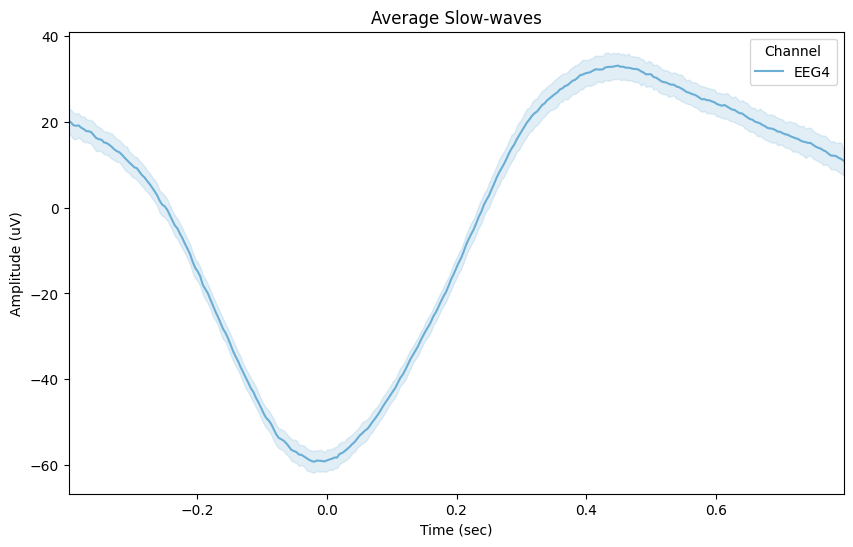

In [113]:
sw.plot_average(ci=99, legend=True, palette='Blues',figsize=(10,6))

plt.title('Average Slow-waves')
plt.show()

## filter out non EEG channels (i.e., Tilt channels) from the SW detection.
##something appears off with the two higher bands (compared to the lower one that is more align with the expected frequency of the YASA demo documentation)

## Automatic Sleep Staging Detection

/var/folders/7d/370678cs0jzdr2slyl3k7m2w0000gn/T/ipykernel_49002/1820398802.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(stage_labels.values())


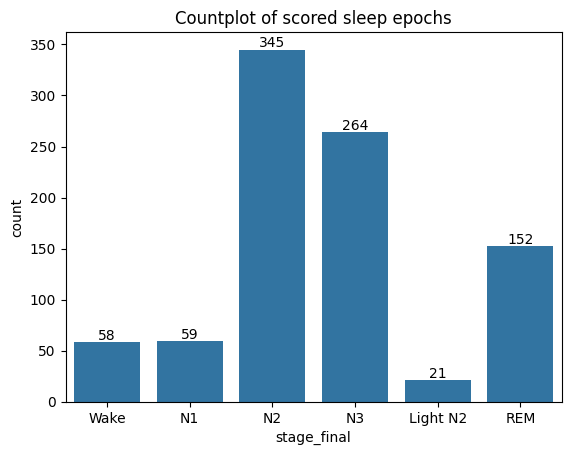

In [142]:
## Count plot of the actual hypogram from Sleep Profiler, epochs of stages sleep breakdown.
## 
ax = sns.countplot(data= hypno_df, x='stage_final')
ax.bar_label(ax.containers[0], label_type = 'edge')

## labels based on SleepProfiler documentation
stage_labels = {
    0 : 'Wake',
    1 : 'N1',
    2 : 'N2',
    3 : 'N3', 
    4 : 'Light N2',
    5 : 'REM'
}

# stage_map = {
#     0 : 'WAKE',
#     1: 'N1',
#     2: 'N2',
#     3: 'N3',
#     4: 'N2', ## Light N2 (Still N2)
#     5: 'REM', 
#     6: 'UNS', ## sleep not otherwise specified
#     9: 'UNS', ## artifact/ INVALID
#     14: 'N2',
#     33: 'N3', ## atypical N3, mapped to N3
#     55: 'REM' ## REM without atonia, mapped to REM
# }

ax.set_xticklabels(stage_labels.values())
ax.set_title('Countplot of scored sleep epochs')
plt.show()

## 899 total count (30s) = 449.5 min, the TIB values from hypnogram.sleep_statistics() below

In [135]:
hypno_df['stage_final'].value_counts()
# 0 : 'Wake', 58 vs 60
# 1 : 'N1', 59 vs 18
# 2 : 'N2', 366 (345 + 21) vs 380
# 3 : 'N3', 264 vs 197
# 4 : 'N5' (Light N2) 21 added to N2
# 5 : 'REM' 152 vs 245

stage_final
2    345
3    264
5    152
1     59
0     58
4     21
Name: count, dtype: int64

In [134]:
## Automatic Sleep Staging Detection 
sls_eeg4 = yasa.SleepStaging(raw_eeg, eeg_name="EEG4")
pred_eeg4 = sls_eeg4.predict()

print(pred_eeg4.hypno.value_counts())

YASA
N2      380
REM     245
N3      197
WAKE     60
N1       18
ART       0
UNS       0
Name: count, dtype: int64


/opt/anaconda3/envs/SleepEEgPy/lib/python3.11/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 0.24.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [ ]:
## Automatic Sleep Staging Detection 
sls_eeg4 = yasa.SleepStaging(raw, eeg_name="EEG4",
                             eog_name='EEG3' ## YASA documentation says preferentially LOC (which is EEG3)

                             )
pred_eeg4 = sls_eeg4.predict()

print(pred_eeg4.hypno.value_counts())


YASA
N2      403
REM     247
N3      187
WAKE     53
N1       10
ART       0
UNS       0
Name: count, dtype: int64


/opt/anaconda3/envs/SleepEEgPy/lib/python3.11/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 0.24.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [156]:
## Automatic Sleep Staging Detection 
sls_eeg4 = yasa.SleepStaging(raw, eeg_name="EEG4",
                             eog_name='EEG3', ## YASA documentation says preferentially LOC (which is EEG3)
                             emg_name ='EEG1', ## Can also specify emg channel (not actually captured in our data.)
                             metadata= {'age':35, 'male':0}
                             )
pred_eeg4 = sls_eeg4.predict()

print(pred_eeg4.hypno.value_counts())

YASA
N2      394
REM     259
N3      186
WAKE     43
N1       18
ART       0
UNS       0
Name: count, dtype: int64


/opt/anaconda3/envs/SleepEEgPy/lib/python3.11/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 0.24.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [ ]:
## Automatic Sleep Staging Detection 
sls_eeg4 = yasa.SleepStaging(raw, eeg_name="EEG4",
                             eog_name='EEG3', ## YASA documentation says preferentially LOC (which is EEG3)
                             emg_name ='EEG1', ## Can also specify emg channel (not actually captured in our data.)
                             metadata= {'age':35, 'male':0} ## Can add metadata to this including age and sex
                             )
pred_eeg4 = sls_eeg4.predict()

print(pred_eeg4.hypno.value_counts())

## Add metadata via a dictionary list from study participant data.
## Decide whether or not to specify EEG1 given this data wasn't actually collected. Would specifying this channel improve accuracy by catching more EMG artifact?

## Plot sleep Staging Probability

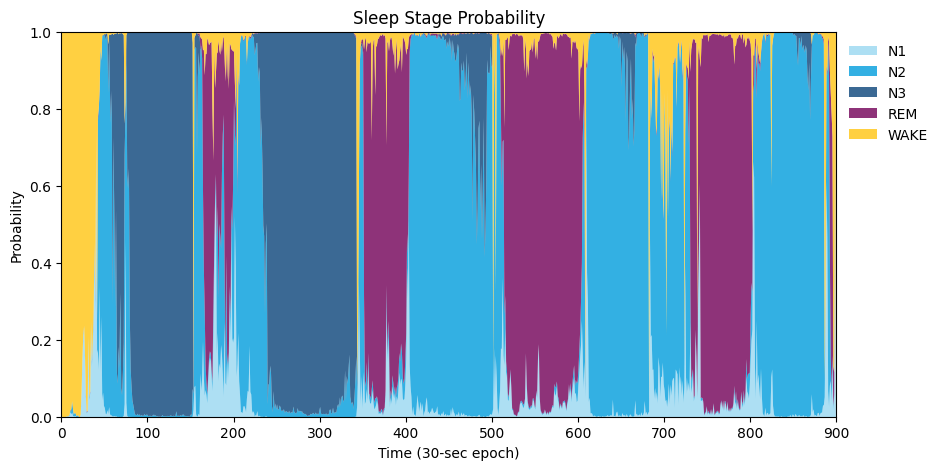

In [ ]:
ax1 = sls_eeg4.plot_predict_proba()

ax1.set_title('Sleep Stage Probability')

plt.show()

## yellow streak in beginning gives credence to the idea of trimming study start/end times in the SleepProfiler matrix (excess time at either end of EEG will lower accuracy of staging proportions)

In [ ]:
## Where to get sleep staging probability (see yasa.SleepStaging to verify this is correct)
pred_eeg4 = sls_eeg4.predict()
pred_eeg4.proba.round(2)

/opt/anaconda3/envs/SleepEEgPy/lib/python3.11/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 0.24.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


,WAKE,N1,N2,N3,REM
Epoch,,,,,
0,0.99,0.00,0.01,0.0,0.00
1,1.00,0.00,0.00,0.0,0.00
2,1.00,0.00,0.00,0.0,0.00
3,1.00,0.00,0.00,0.0,0.00
4,0.99,0.01,0.00,0.0,0.00
...,...,...,...,...,...
895,0.07,0.19,0.04,0.0,0.70
896,0.52,0.24,0.03,0.0,0.21
897,0.85,0.10,0.01,0.0,0.04
